In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
df=pd.read_csv("C:\\Users\\Harshitha\\OneDrive\\Desktop\\Retail-Intelligence-Platform\\data\\cleaned_superstore.csv")

In [19]:
df["Order.Date"]=pd.to_datetime(df["Order.Date"])

In [5]:
print(df["Order.Date"].head())

0   2011-01-07
1   2011-01-21
2   2011-08-05
3   2011-08-05
4   2011-09-29
Name: Order.Date, dtype: datetime64[us]


In [9]:
high_sales=df[df["Sales"]>1000]
print(high_sales.head())

            Category         City        Country Customer.ID  \
196  Office Supplies  Los Angeles  United States   RS-197654   
221  Office Supplies  Los Angeles  United States   PF-192254   
258  Office Supplies  Los Angeles  United States   HG-150254   
280  Office Supplies  Los Angeles  United States   PV-189854   
298  Office Supplies  Los Angeles  United States   SC-204404   

         Customer.Name  Discount Market               Order.Date  \
196     Roland Schwarz       0.0     US  2011-12-06 00:00:00.000   
221  Phillip Flathmann       0.0     US  2013-11-04 00:00:00.000   
258      Hunter Glantz       0.0     US  2012-05-14 00:00:00.000   
280      Paul Van Hugh       0.0     US  2014-10-03 00:00:00.000   
298       Shaun Chance       0.0     US  2012-09-24 00:00:00.000   

           Order.ID Order.Priority  ... Sales      Segment  \
196  CA-2011-106726       Critical  ...  1261    Corporate   
221  CA-2013-114972       Critical  ...  1101     Consumer   
258  CA-2012-165162 

In [13]:
loss_sales=df[df["Profit"]<00]
print(loss_sales.head())

         Category                 City Country Customer.ID  Customer.Name  \
29009  Technology                Paris  France   RC-198252    Roy Collins   
29012  Technology              Taverny  France   TB-211752  Thomas Boland   
29018  Technology   Tremblay-en-France  France   DH-130752  Dave Hallsten   
29021  Technology           Guyancourt  France   MH-174552  Mark Hamilton   
29024  Technology  Le Plessis-Robinson  France   AA-104802   Andrew Allen   

       Discount Market               Order.Date         Order.ID  \
29009      0.15     EU  2011-04-26 00:00:00.000  IT-2011-2185983   
29012      0.15     EU  2011-08-26 00:00:00.000  ES-2011-5235241   
29018      0.15     EU  2011-12-02 00:00:00.000  ES-2011-4614329   
29021      0.15     EU  2012-06-07 00:00:00.000  ES-2012-2141914   
29024      0.15     EU  2012-08-30 00:00:00.000  IT-2012-5602177   

      Order.Priority  ... Sales    Segment                Ship.Date  \
29009       Critical  ...   684   Consumer  2011-04-27 00

In [14]:
highest_sales=df.sort_values(by="Sales",ascending=False)
print(highest_sales.head())

         Category           City        Country Customer.ID Customer.Name  \
47257  Technology   Jacksonville  United States   SM-203204   Sean Miller   
27727  Technology      Lafayette  United States   TC-209804  Tamara Chand   
28327  Technology        Seattle  United States   RB-193604  Raymond Buch   
48073  Technology  New York City  United States   TA-213854  Tom Ashbrook   
27524  Technology         Newark  United States   HL-150404  Hunter Lopez   

       Discount Market               Order.Date        Order.ID  \
47257       0.5     US  2011-03-18 00:00:00.000  CA-2011-145317   
27727       0.0     US  2013-10-03 00:00:00.000  CA-2013-118689   
28327       0.0     US  2014-03-24 00:00:00.000  CA-2014-140151   
48073       0.2     US  2014-10-23 00:00:00.000  CA-2014-127180   
27524       0.0     US  2014-11-18 00:00:00.000  CA-2014-166709   

      Order.Priority  ...  Sales      Segment                Ship.Date  \
47257         Medium  ...  22638  Home Office  2011-03-23 00

In [15]:
top_profit_products=df.groupby("Product.Name")["Profit"].sum().sort_values(ascending=False).head(10)
print(top_profit_products)

Product.Name
Canon imageCLASS 2200 Advanced Copier                       25199.9280
Cisco Smart Phone, Full Size                                17238.5206
Motorola Smart Phone, Full Size                             17027.1130
Hoover Stove, Red                                           11807.9690
Sauder Classic Bookcase, Traditional                        10672.0730
Harbour Creations Executive Leather Armchair, Adjustable    10427.3260
Nokia Smart Phone, Full Size                                 9938.1955
Cisco Smart Phone, with Caller ID                            9786.6408
Nokia Smart Phone, with Caller ID                            9465.3257
Belkin Router, USB                                           8955.0180
Name: Profit, dtype: float64


In [16]:
pivot = pd.pivot_table(
    df,
    values="Sales",
    index="Category",
    columns="Region",
    aggfunc="sum"
)

print(pivot)

Region           Africa  Canada  Caribbean  Central  Central Asia    EMEA  \
Category                                                                    
Furniture        194650   10595     118379   860413        284369  228627   
Office Supplies  266752   30037      89565   923471        162768  276712   
Technology       322374   26300     116337  1038515        305702  300845   

Region             East   North  North Asia  Oceania   South  Southeast Asia  \
Category                                                                       
Furniture        208291  377612      335725   410473  515739          313391   
Office Supplies  205549  374778      198581   281729  515208          241299   
Technology       264994  495802      314043   408005  570013          329748   

Region             West  
Category                 
Furniture        252620  
Office Supplies  220881  
Technology       252013  


In [20]:
df["Month"]=df["Order.Date"].dt.month_name()

In [21]:
monthly_sales=df.groupby("Month")["Sales"].sum()
print(monthly_sales)

Month
April         698603
August       1293852
December     1580816
February      543768
January       675141
July          749423
June         1269751
March         770519
May           904061
November     1551319
October      1168220
September    1437432
Name: Sales, dtype: int64


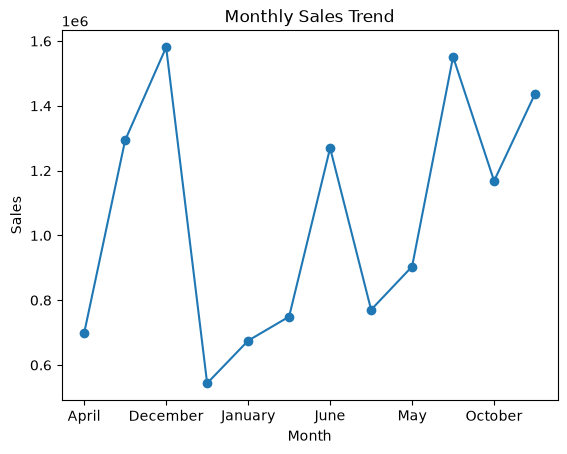

In [23]:
monthly_sales.plot(marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()


In [24]:
region_profit=df.groupby("Region")["Profit"].sum()
print(region_profit)

Region
Africa             88871.63100
Canada             17817.39000
Caribbean          34571.32104
Central           311403.98164
Central Asia      132480.18700
EMEA               43897.97100
East               91522.78000
North             194597.95252
North Asia        165578.42100
Oceania           120089.11200
South             140355.76618
Southeast Asia     17852.32900
West              108418.44890
Name: Profit, dtype: float64


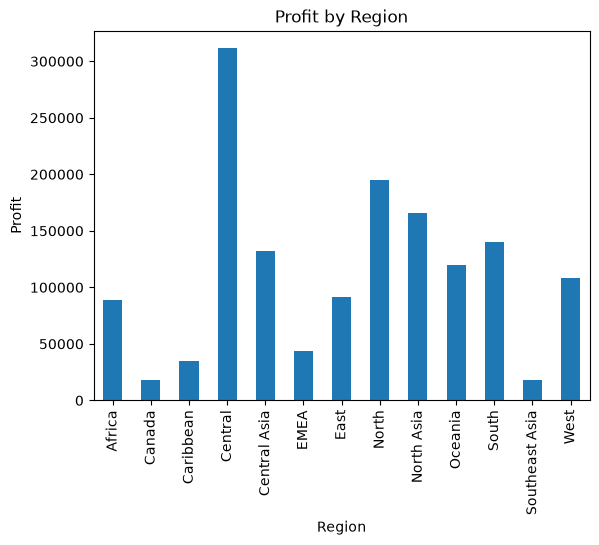

In [25]:
region_profit.plot(kind="bar")
plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Profit")
plt.show()